In [ ]:
!pip install kumoai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.9/357.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 7.6 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/neo4j-contrib/northwind-neo4j

Cloning into 'northwind-neo4j'...
remote: Enumerating objects: 207, done.
remote: Total 207 (delta 0), reused 0 (delta 0), pack-reused 207 (from 1)
Receiving objects: 100% (207/207), 7.10 MiB | 16.68 MiB/s, done.
Resolving deltas: 100% (60/60), done.


In [ ]:
import kumoai.experimental.rfm as rfm, os
import pandas as pd

In [ ]:
KUMO_API_KEY = os.environ.get("KUMO_API_KEY")
rfm.init(api_key=KUMO_API_KEY)

INFO:kumoai:Initialized Kumo SDK v2.15.0 against deployment 'https://kumorfm.ai/api'


In [ ]:
os.listdir("northwind-neo4j/data")

['products.csv',
 'suppliers.csv',
 'employees.csv',
 'categories.csv',
 'employee-territories.csv',
 'shippers.csv',
 'regions.csv',
 'customers.csv',
 'territories.csv',
 'orders.csv',
 'order-details.csv']

In [ ]:
root_path = "./northwind-neo4j/data/"

In [ ]:
def read_csv_file(filename):
  return pd.read_csv(
    root_path + filename,
    sep=",",
    quotechar='"',
    on_bad_lines='skip'
  )

In [ ]:
customers = read_csv_file("customers.csv")
regions = read_csv_file("regions.csv")
shippers = read_csv_file("shippers.csv")
territories = read_csv_file("territories.csv")
employee_territories = read_csv_file("employee-territories.csv")
employees = read_csv_file("employees.csv")
products = read_csv_file("products.csv")
categories = read_csv_file("categories.csv")
suppliers = read_csv_file("suppliers.csv")
orders = read_csv_file("orders.csv")
order_details = read_csv_file("order-details.csv")

### 🗂️ Graph Metadata

Name,Primary Key,Time Column,End Time Column
customers,customerID,-,-
regions,regionID,-,-
shippers,shipperID,-,-
territories,territoryID,-,-
employee_territories,-,-,-
employees,employeeID,birthDate,-
products,productID,-,-
categories,categoryID,-,-
suppliers,supplierID,-,-
orders,orderID,orderDate,-


### 🕸️ Graph Links (FK ↔️ PK)

- `products.categoryID` ↔️ `categories.categoryID`
- `orders.customerID` ↔️ `customers.customerID`
- `employee_territories.employeeID` ↔️ `employees.employeeID`
- `orders.employeeID` ↔️ `employees.employeeID`
- `order_details.orderID` ↔️ `orders.orderID`
- `products.unitsOnOrder` ↔️ `orders.orderID`
- `order_details.productID` ↔️ `products.productID`
- `territories.regionID` ↔️ `regions.regionID`
- `products.supplierID` ↔️ `suppliers.supplierID`
- `employee_territories.territoryID` ↔️ `territories.territoryID`

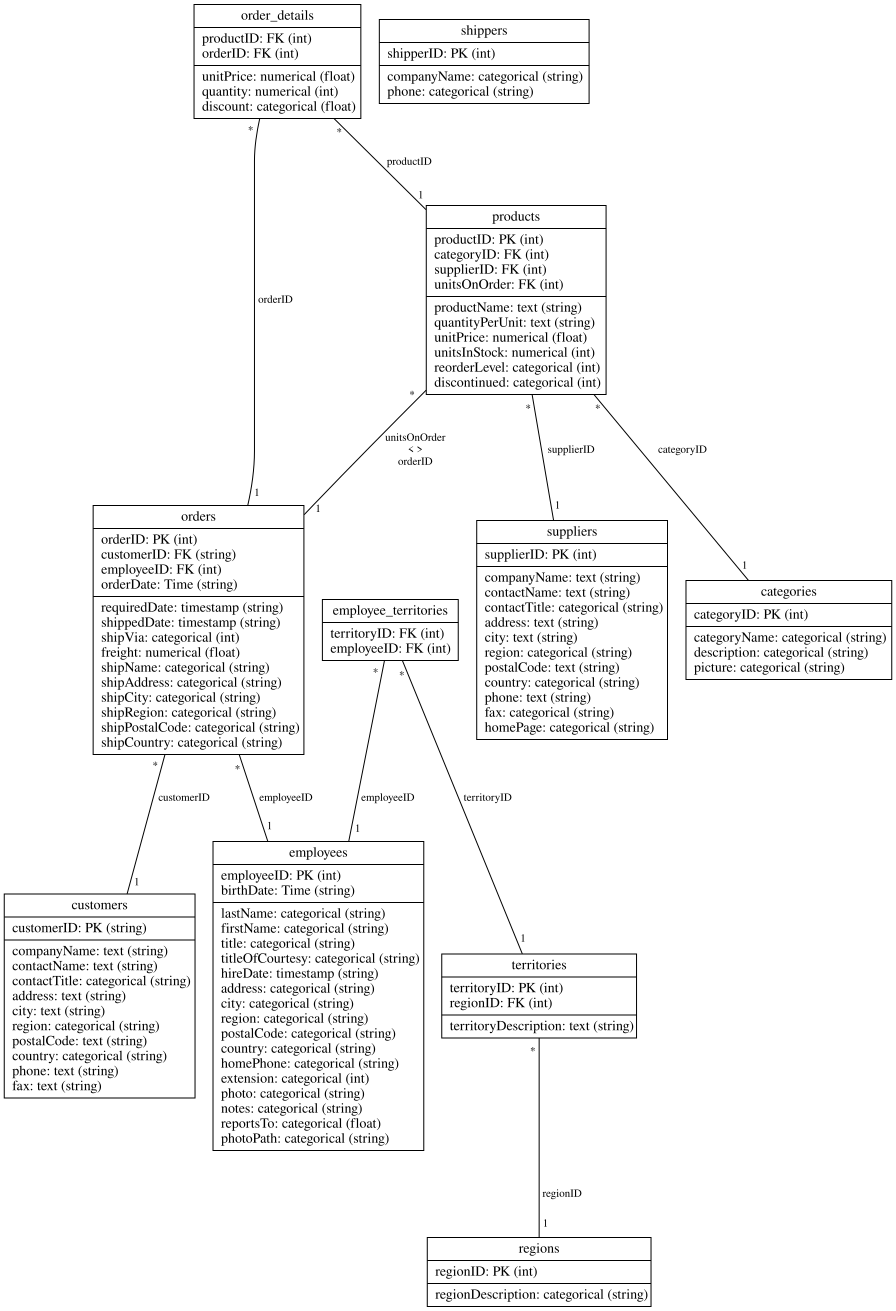

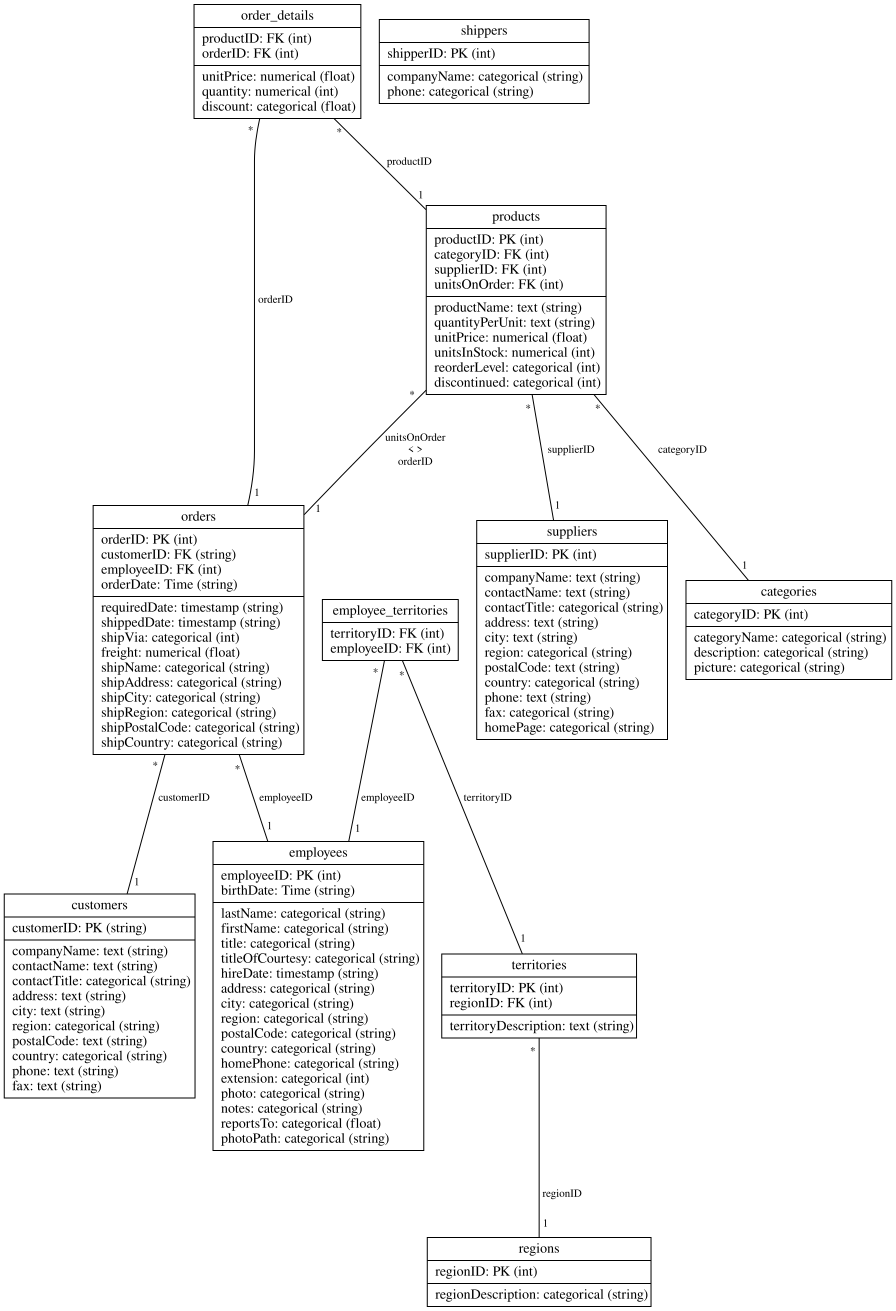

In [ ]:
graph = rfm.LocalGraph.from_data({
    "customers": customers,
    "regions": regions,
    "shippers": shippers,
    "territories": territories,
    "employee_territories": employee_territories,
    "employees": employees,
    "products": products,
    "categories": categories,
    "suppliers": suppliers,
    "orders": orders,
    "order_details": order_details
})

graph.visualize()

In [ ]:
model = rfm.KumoRFM(graph)

Output()

In [ ]:
order_details.head()

,orderID,productID,unitPrice,quantity,discount
0,10248,11,14.0,12,0.0
1,10248,42,9.8,10,0.0
2,10248,72,34.8,5,0.0
3,10249,14,18.6,9,0.0
4,10249,51,42.4,40,0.0


In [ ]:
customers.head()

,customerID,companyName,contactName,contactTitle,address,city,region,postalCode,country,phone,fax
0,ALFKI,Alfreds Futterkiste,Maria Anders,Sales Representative,Obere Str. 57,Berlin,NaN,12209,Germany,030-0074321,030-0076545
1,ANATR,Ana Trujillo Emparedados y helados,Ana Trujillo,Owner,Avda. de la Constitución 2222,México D.F.,NaN,05021,Mexico,(5) 555-4729,(5) 555-3745
2,ANTON,Antonio Moreno Taquería,Antonio Moreno,Owner,Mataderos 2312,México D.F.,NaN,05023,Mexico,(5) 555-3932,NaN
3,AROUT,Around the Horn,Thomas Hardy,Sales Representative,120 Hanover Sq.,London,NaN,WA1 1DP,UK,(171) 555-7788,(171) 555-6750
4,BERGS,Berglunds snabbköp,Christina Berglund,Order Administrator,Berguvsvägen 8,Luleå,NaN,S-958 22,Sweden,0921-12 34 65,0921-12 34 67


In [ ]:
orders["orderDate"].max() #This should be the anchor_timestamp

'1998-05-06 00:00:00.000'

In [ ]:
# LOGIC: Predict if a customer will place 0 orders in the next 30 days (churn).
# FILTER: Only look at customers who placed at least one order in the last 90 days.
query = """
PREDICT COUNT(orders.*, 0, 30, days) = 0
FOR EACH customers.customerID
WHERE COUNT(orders.*, -90, 0, days) > 0
"""

customer_ids = customers['customerID'].tolist()
df = model.predict(query, indices=customer_ids)
display(df)

# ENTITY           -> The unique Customer ID (e.g., 'ALFKI').
# ANCHOR_TIMESTAMP -> The "cutoff" date. Data before this is used to predict the future.
# TARGET_PRED      -> The final prediction.
#                     True  = "Yes, they will likely have 0 orders" (Churner).
#                     False = "No, they will likely place an order" (Retained).
# False_PROB       -> The probability (0 to 1) that the customer WILL order.
# True_PROB        -> The probability (0 to 1) that the customer WILL NOT order.

Output()

,ENTITY,ANCHOR_TIMESTAMP,TARGET_PRED,False_PROB,True_PROB
0,ALFKI,1998-05-06,True,0.450199,0.549801
1,ANATR,1998-05-06,True,0.267747,0.732253
2,ANTON,1998-05-06,True,0.342918,0.657082
3,AROUT,1998-05-06,False,0.744785,0.255215
4,BERGS,1998-05-06,False,0.595727,0.404273
...,...,...,...,...,...
62,WANDK,1998-05-06,False,0.500488,0.499512
63,WARTH,1998-05-06,False,0.516103,0.483897
64,WHITC,1998-05-06,False,0.527264,0.472736
65,WILMK,1998-05-06,True,0.462482,0.537518


/tmp/ipython-input-3380876737.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_risk, x='ENTITY', y='True_PROB', ax=axes[0], palette='Reds_r')


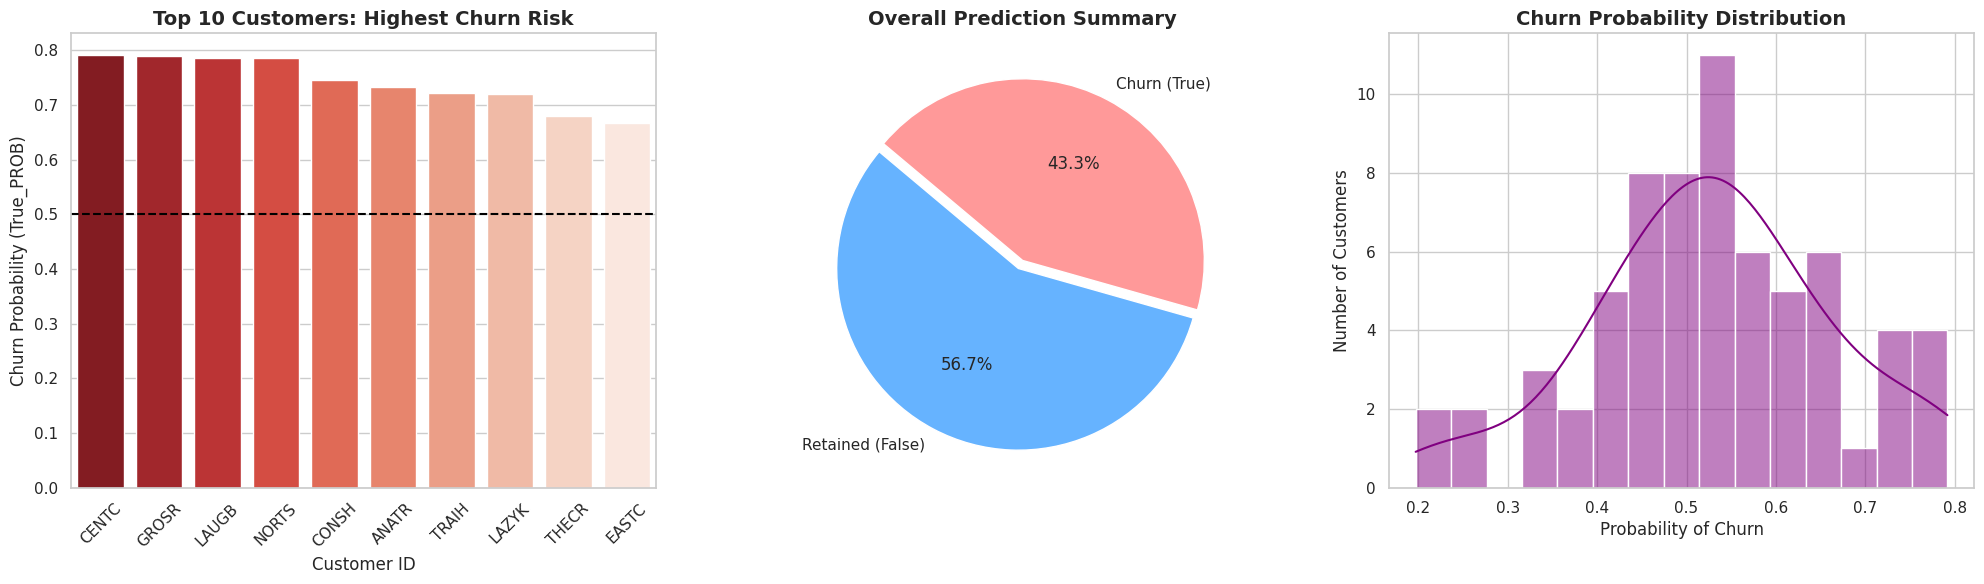

--- CUSTOMERS TO CONTACT IMMEDIATELY (Probability > 70%) ---


,ENTITY,True_PROB
9,CENTC,0.791644
20,GROSR,0.789644
27,LAUGB,0.786367
38,NORTS,0.785553
11,CONSH,0.745484
1,ANATR,0.732253
59,TRAIH,0.721346
28,LAZYK,0.719524


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

top_10_risk = df.sort_values(by='True_PROB', ascending=False).head(10)
sns.barplot(data=top_10_risk, x='ENTITY', y='True_PROB', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Customers: Highest Churn Risk', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Churn Probability (True_PROB)')
axes[0].set_xlabel('Customer ID')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(0.5, color='black', linestyle='--')

target_counts = df['TARGET_PRED'].value_counts()
axes[1].pie(target_counts, labels=['Retained (False)', 'Churn (True)'],
            autopct='%1.1f%%', startangle=140, colors=['#66b3ff', '#ff9999'],
            explode=(0.05, 0))
axes[1].set_title('Overall Prediction Summary', fontsize=14, fontweight='bold')


sns.histplot(df['True_PROB'], bins=15, kde=True, ax=axes[2], color='purple')
axes[2].set_title('Churn Probability Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Probability of Churn')
axes[2].set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print("--- CUSTOMERS TO CONTACT IMMEDIATELY (Probability > 70%) ---")
high_alert = df[df['True_PROB'] > 0.7].sort_values(by='True_PROB', ascending=False)
display(high_alert[['ENTITY', 'True_PROB']])

In [ ]:
# Regression Test
# LOGIC: Predict the total shipping costs (freight) a customer will generate in the next 90 days.
query_freight = """
PREDICT SUM(orders.freight, 0, 90, days)
FOR EACH customers.customerID
"""

customer_ids = customers['customerID'].tolist()
df_freight = model.predict(query_freight, indices=customer_ids)

display(df_freight.head())

# ENTITY           -> The unique Customer ID (e.g., 'ALFKI').
# ANCHOR_TIMESTAMP -> The "cutoff" date. The model looks at history before this to forecast after it.
# TARGET_PRED      -> The predicted dollar amount of freight costs for the next 90 days.
#                     (e.g., 124.50 means the model expects $124.50 in shipping fees).

Output()

,ENTITY,ANCHOR_TIMESTAMP,TARGET_PRED
0,ALFKI,1998-05-06,54.457226
1,ANATR,1998-05-06,9.459248
2,ANTON,1998-05-06,20.409691
3,AROUT,1998-05-06,62.706688
4,BERGS,1998-05-06,96.028488


In [ ]:
order_details

,orderID,productID,unitPrice,quantity,discount
0,10248,11,14.00,12,0.00
1,10248,42,9.80,10,0.00
2,10248,72,34.80,5,0.00
3,10249,14,18.60,9,0.00
4,10249,51,42.40,40,0.00
...,...,...,...,...,...
2150,11077,64,33.25,2,0.03
2151,11077,66,17.00,1,0.00
2152,11077,73,15.00,2,0.01
2153,11077,75,7.75,4,0.00


In [ ]:
# LOGIC: Predict how many orders each employee will handle in the next 60 days.
query = """
PREDICT COUNT(orders.*, 0, 60, days)
FOR EACH employees.employeeID
"""

employee_ids = employees['employeeID'].tolist()
df_emp_revenue = model.predict(query, indices=employee_ids)
display(df_emp_revenue.head())

# ENTITY           -> The unique Employee ID.
# ANCHOR_TIMESTAMP -> The cutoff date. All order history before this date is used
#                     as input features to forecast the next 60 days.
# TARGET_PRED      -> The predicted number of orders this employee will handle
#                     in the next 60 days.
#                     (e.g., 12.3 means the model expects ~12 orders from this employee).

Output()

,ENTITY,ANCHOR_TIMESTAMP,TARGET_PRED
0,1,1998-05-06,8.496538
1,2,1998-05-06,5.913977
2,3,1998-05-06,9.084134
3,4,1998-05-06,9.826354
4,5,1998-05-06,3.450175


In [ ]:
def dummy_query(i):
    global count, max_steps
    query = """
    PREDICT COUNT(orders.*, 0, 60, days)
    FOR EACH employees.employeeID
    """
    employee_ids = employees['employeeID'].tolist()

    try:
        df_emp_revenue = model.predict(query, indices=employee_ids)
        with count_lock:
            count += 1
            print(f"\n[{count}/{max_steps}] Query {i} succeeded\n", flush=True)
        return True
    except Exception as e:
        with count_lock:
            count += 1
            print(f"\n[{count}/{max_steps}] Query {i} FAILED: {e}\n", flush=True)
        return False

In [ ]:
#Let's test how many queries can be executed at once on the free tier
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed

count = 0
count_lock = threading.Lock()
max_steps = 5

with ThreadPoolExecutor(max_workers=2) as executor:
    futures = {executor.submit(dummy_query, i): i for i in range(max_steps)}

    for future in as_completed(futures):
        result = future.result()
        if not result:
            print("--- Rate limit or error hit, stopping ---", flush=True)
            executor.shutdown(wait=False, cancel_futures=True)
            break

Output()


[1/5] Query 0 succeeded



Output()

[2/5] Query 1 FAILED: Only one live display may be active at once

--- Rate limit or error hit, stopping ---


[3/5] Query 2 succeeded



Output()


[4/5] Query 3 succeeded



In [ ]:
# Based on this only one live display may be active at once

In [ ]:
# On the FAQ page it says that the limit of the free tier is 1000 calls daily so let's put that to the test
# And see the error.

count = 0
max_steps = 10000
for i in range(max_steps):
  result = dummy_query(i)
  if not result:
    print("--- Rate limit or error hit, stopping ---", flush=True)
    break

Output()


[1/10000] Query 0 FAILED: An unexpected exception occurred. Please create an issue at 'https://github.com/kumo-ai/kumo-rfm'. {"error":"Rate limit exceeded: 1000 per 1 day"}

--- Rate limit or error hit, stopping ---


In [ ]:
dummy_query(0)

Output()

NameError: name 'count_lock' is not defined

In [ ]:
len(customers) + len(regions) + len(shippers) + len(territories) + len(employee_territories) + len(employees) + len(products) + len(categories) + len(suppliers) + len(orders) + len(order_details)

3099

In [ ]:
#This dataset has 3099 rows

In [ ]:
!gdown 1F5KFYQnYDpxFe1ASEpcNL1ZPBxhCvlyt

Downloading...
From (original): https://drive.google.com/uc?id=1F5KFYQnYDpxFe1ASEpcNL1ZPBxhCvlyt
From (redirected): https://drive.google.com/uc?id=1F5KFYQnYDpxFe1ASEpcNL1ZPBxhCvlyt&confirm=t&uuid=f168e56d-fecf-4f26-9bd2-0599573bb61b
To: /content/movielens20m.zip
100% 205M/205M [00:03<00:00, 52.6MB/s]


In [ ]:
!unzip movielens20m.zip -d movielens20m

Archive:  movielens20m.zip
  inflating: movielens20m/genome_scores.csv  
  inflating: movielens20m/genome_tags.csv  
  inflating: movielens20m/link.csv   
  inflating: movielens20m/movie.csv  
  inflating: movielens20m/rating.csv  
  inflating: movielens20m/tag.csv    


In [ ]:
os.listdir("./movielens20m")

['movie.csv',
 'link.csv',
 'genome_tags.csv',
 'rating.csv',
 'genome_scores.csv',
 'tag.csv']

In [ ]:
# Test with larger dataset
root_path = "./movielens20m/"
movie = read_csv_file("movie.csv")
link = read_csv_file("link.csv")
genome_tags = read_csv_file("genome_tags.csv")
rating = read_csv_file('rating.csv')
genome_scores = read_csv_file("genome_scores.csv")
tag = read_csv_file("tag.csv")

In [ ]:
total_length = len(movie) + len(link) + len(genome_tags) + len(rating) + len(genome_scores) + len(tag)
print(f"{total_length:,}".replace(",", "."))

32.231.279


In [ ]:
# This dataset contains 32M rows

### 🗂️ Graph Metadata

Name,Primary Key,Time Column,End Time Column
movie,movieId,-,-
link,-,-,-
genome_tags,-,-,-
rating,-,timestamp,-
genome_scores,-,-,-
tag,-,timestamp,-


### 🕸️ Graph Links (FK ↔️ PK)

- `genome_scores.movieId` ↔️ `movie.movieId`
- `link.movieId` ↔️ `movie.movieId`
- `rating.movieId` ↔️ `movie.movieId`
- `tag.movieId` ↔️ `movie.movieId`

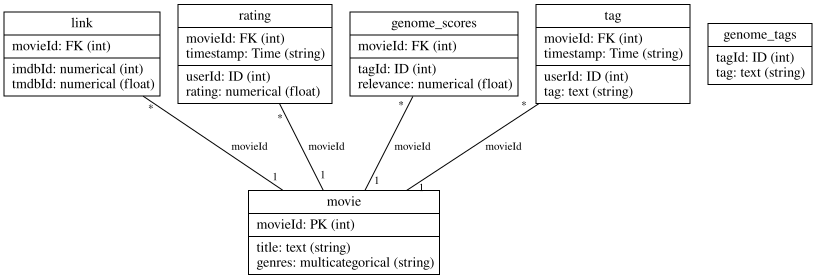

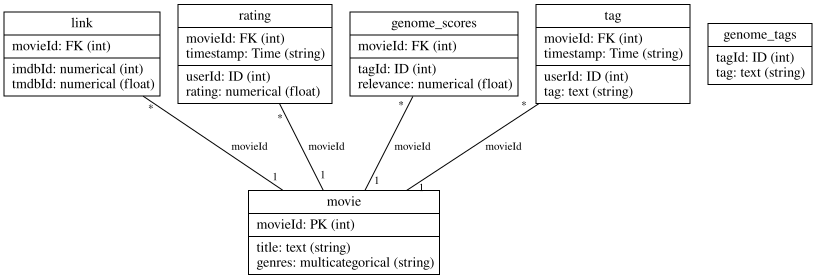

In [ ]:
graph = rfm.LocalGraph.from_data({
    "movie": movie,
    "link": link,
    "genome_tags": genome_tags,
    "rating": rating,
    "genome_scores": genome_scores,
    "tag": tag,
})

graph.visualize()

In [ ]:
model = rfm.KumoRFM(graph)

Output()

In [ ]:
movie

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
27273,131254,Kein Bund für's Leben (2007),Comedy
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy
27275,131258,The Pirates (2014),Adventure
27276,131260,Rentun Ruusu (2001),(no genres listed)


In [ ]:
rating

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40
...,...,...,...,...
20000258,138493,68954,4.5,2009-11-13 15:42:00
20000259,138493,69526,4.5,2009-12-03 18:31:48
20000260,138493,69644,3.0,2009-12-07 18:10:57
20000261,138493,70286,5.0,2009-11-13 15:42:24


In [ ]:
query = """
PREDICT COUNT(rating.*, 0, 90, days) = 0
FOR EACH movie.movieId
"""

movie_ids = movie['movieId'].tolist()
df = model.predict(query, indices=movie_ids)
display(df)

Output()

ValueError: Cannot predict for more than 1,000 entities at once (got 27,278). Use `KumoRFM.batch_mode` to process entities in batches with a sufficient batch size.

In [ ]:
# A large number of entities must be batched

In [ ]:
# LOGIC: Predict the probability that a movie will receive NO new ratings at all in the next 90 days (identifying "stale" or inactive content).
query = """
PREDICT COUNT(rating.*, 0, 90, days) = 0
FOR EACH movie.movieId
"""

movie_ids = movie['movieId'].tolist()
with model.batch_mode(batch_size="max", num_retries=1):
    df = model.predict(query, indices=movie_ids)
    display(df)

Output()

,ENTITY,ANCHOR_TIMESTAMP,TARGET_PRED,False_PROB,True_PROB
0,1,2015-03-31 06:40:02,False,0.997444,0.002556
1,2,2015-03-31 06:40:02,False,0.989996,0.010004
2,3,2015-03-31 06:40:02,False,0.868329,0.131671
3,4,2015-03-31 06:40:02,False,0.589991,0.410009
4,5,2015-03-31 06:40:02,False,0.765777,0.234223
...,...,...,...,...,...
27273,131254,2015-03-31 06:40:02,True,0.136384,0.863616
27274,131256,2015-03-31 06:40:02,True,0.144150,0.855850
27275,131258,2015-03-31 06:40:02,True,0.200097,0.799903
27276,131260,2015-03-31 06:40:02,True,0.259075,0.740925


In [ ]:
# LOGIC: Predict the average quality score (rating) a movie will receive from users over the next 3 months
query = """
PREDICT AVG(rating.rating, 0, 90, days)
FOR EACH movie.movieId
"""

movie_ids = movie['movieId'].tolist()
with model.batch_mode(batch_size="max", num_retries=1):
    df = model.predict(query, indices=movie_ids)
    display(df)

Output()

,ENTITY,ANCHOR_TIMESTAMP,TARGET_PRED
0,1,2015-03-31 06:40:02,3.393780
1,2,2015-03-31 06:40:02,3.253288
2,3,2015-03-31 06:40:02,3.236367
3,4,2015-03-31 06:40:02,2.327427
4,5,2015-03-31 06:40:02,3.001470
...,...,...,...
27273,131254,2015-03-31 06:40:02,3.451554
27274,131256,2015-03-31 06:40:02,3.501551
27275,131258,2015-03-31 06:40:02,3.475170
27276,131260,2015-03-31 06:40:02,3.512968


In [ ]:
# Also you can connect to BigQuery databases and more.
# More on this link: https://kumo-ai.github.io/kumo-sdk/docs/modules/connector.html
# But on all the examples in the docs the rows were read in memory so if the database is big I think we must use a sample of the data and not the full dataset.